# load the llm model

In [1]:
#load the llm
from langchain_groq import ChatGroq
from dotenv import load_dotenv
# Load environment variables
load_dotenv()
import os

# Initialize LLM
llm = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="qwen/qwen3-32b"
)

# Invoke model
response = llm.invoke("Hi")
print(response)

/Users/arunrajselvarasu/Documents/RagUdemy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


content='<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly way. Maybe ask how I can help them today. Keep it open-ended so they can specify what they need. Let me make sure the tone is welcoming and approachable.\n</think>\n\nHello! How can I assist you today? 😊' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 9, 'total_tokens': 79, 'completion_time': 0.14528449, 'prompt_time': 0.000604865, 'queue_time': 0.160039656, 'total_time': 0.145889355}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='run--019eb7b9-52be-7bb0-873c-c2f9f856e3ab-0' usage_metadata={'input_tokens': 9, 'output_tokens': 70, 'total_tokens': 79}


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import START,END,StateGraph

#reducers

from typing import Annotated
from langgraph.graph import add_messages


In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [12]:
def chatbot(state:State):
    return  {"messages":[llm.invoke(state['messages'])]}

In [15]:
graph = StateGraph(State)

In [16]:
#node
graph.add_node("superbot",chatbot)


#edges
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

In [17]:
#compile

graph_builder = graph.compile()

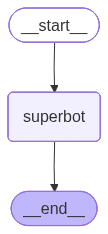

In [18]:
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [19]:
graph_builder.invoke({'messages':"What is LLM?"})

{'messages': [HumanMessage(content='What is LLM?', additional_kwargs={}, response_metadata={}, id='e218b171-e7c3-4b2e-b8c7-4fc2ba3f4296'),
  AIMessage(content='<think>\nOkay, I need to explain what an LLM is. Let me start by recalling what I know. LLM stands for Large Language Model. They are a type of machine learning model that\'s used for understanding and generating human language.\n\nFirst, I should define the basics. LLMs are trained on vast amounts of text data. This helps them learn the patterns, grammar, and nuances of language. They can perform tasks like translation, summarization, answering questions, and even writing stories or code.\n\nI should mention the architecture, like transformers. Transformers use attention mechanisms, which allow the model to weigh the importance of different parts of the input. This is different from older models like RNNs, which process information sequentially and can have issues with long-range dependencies.\n\nTraining is a big part. LLMs ar